1. In This part i have loaded the dataset and imported the csv file and shown the first five rows of the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('data.csv') 


# Quick look
print("Shape:", df.shape)
df.head()

Shape: (168029, 13)


,product_name,brand_name,rating,rating_count,marked_price,discounted_price,sizes,product_link,img_link,product_tag,brand_tag,discount_amount,discount_percent
0,Croc Textured Two Fold Wallet,Lino Perros,0.0,0,1295,828,Onesize,wallets/lino-perros/lino-perros-women-peach-co...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",wallets,lino-perros,467,36
1,Men Striped Sliders,Mast & Harbour,4.0,76,1299,584,"UK6,UK7,UK8,UK9,UK10,UK11",flip-flops/mast--harbour/mast--harbour-men-nav...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",flip-flops,mast--harbour,715,55
2,Printed A-line Kurta,Biba,4.3,66,1999,1599,"S,M,L,XL,XXL,3XL",kurtas/biba/biba-women-off-white--black-printe...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurtas,biba,400,20
3,Girls Floral Printed T-shirt,Anthrilo,0.0,0,599,539,"7-8Y,8-9Y,9-10Y",tshirts/anthrilo/anthrilo-girls-white-floral-p...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",tshirts,anthrilo,60,10
4,Women Printed Kurta with Skirt,FASHION DWAR,0.0,0,2899,2899,"S,M,L,XL",kurta-sets/fashion-dwar/fashion-dwar-women-mul...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurta-sets,fashion-dwar,0,0


2. In this part i have done i have just seen column names or the data type 

In [4]:
# Column info
df.info()

# Summary stats
df.describe()

# Check column names
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168029 entries, 0 to 168028
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   product_name      168029 non-null  object 
 1   brand_name        168029 non-null  object 
 2   rating            168029 non-null  float64
 3   rating_count      168029 non-null  int64  
 4   marked_price      168029 non-null  int64  
 5   discounted_price  168029 non-null  int64  
 6   sizes             168029 non-null  object 
 7   product_link      168029 non-null  object 
 8   img_link          168029 non-null  object 
 9   product_tag       168029 non-null  object 
 10  brand_tag         168029 non-null  object 
 11  discount_amount   168029 non-null  int64  
 12  discount_percent  168029 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 16.7+ MB


['product_name',
 'brand_name',
 'rating',
 'rating_count',
 'marked_price',
 'discounted_price',
 'sizes',
 'product_link',
 'img_link',
 'product_tag',
 'brand_tag',
 'discount_amount',
 'discount_percent']

3. this column checks the missing values and and there is then we will fill them with median and categorical column will be filled with mode we have not used mean because if there conist of some values in middle like high price that makes an issue 

In [6]:
# Check missing values
print(df.isnull().sum())
print((df.isnull().sum() / len(df)) * 100)

# Fill discounted_price with MEDIAN
df['discounted_price'].fillna(df['discounted_price'].median(), inplace=True)

# Fill marked_price with MEDIAN (if exists)
if 'marked_price' in df.columns:
    df['marked_price'].fillna(df['marked_price'].median(), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Check again
print("\n✅ Missing values after cleaning:")
print(df.isnull().sum())

product_name        0
brand_name          0
rating              0
rating_count        0
marked_price        0
discounted_price    0
sizes               0
product_link        0
img_link            0
product_tag         0
brand_tag           0
discount_amount     0
discount_percent    0
dtype: int64
product_name        0.0
brand_name          0.0
rating              0.0
rating_count        0.0
marked_price        0.0
discounted_price    0.0
sizes               0.0
product_link        0.0
img_link            0.0
product_tag         0.0
brand_tag           0.0
discount_amount     0.0
discount_percent    0.0
dtype: float64

✅ Missing values after cleaning:
product_name        0
brand_name          0
rating              0
rating_count        0
marked_price        0
discounted_price    0
sizes               0
product_link        0
img_link            0
product_tag         0
brand_tag           0
discount_amount     0
discount_percent    0
dtype: int64


4. In this i have just check the duplicates values and removed them 

In [8]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)



Duplicate rows: 0


5. In this i have found the outliers that are present in the dataset in this i have not directly removed the outlier i have done a small thing i have made a list in which i have filled the luxury brands if this found in outlier list then it will not be removed it will remove only cheap product with hight values and removes only suspicious one depending on higher price but brand not premeuim 

In [18]:
# STEP 1: Find outliers on discount_price
Q1 = df['discounted_price'].quantile(0.25)
Q3 = df['discounted_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (df['discounted_price'] < lower) | (df['discounted_price'] > upper)

# STEP 2: Don't remove immediately - investigate first
outlier_data = df[outliers]
print(f"Found {len(outlier_data)} outliers")

# STEP 3: Check if they're genuine products
# Look at product names, brands - are they premium brands?
premium_brands = ['ASIAN', 'H&M', 'ID', 'roadster']  # Add your own list
genuine_outliers = outlier_data[outlier_data['brand_name'].isin(premium_brands)]
print(f"Genuine premium outliers: {len(genuine_outliers)}")

# STEP 4: Only remove suspicious ones (cheap products with high price errors)
# Remove only if price > 50,000 and brand is not premium
suspicious = outlier_data[~outlier_data['brand_name'].isin(premium_brands)]
df_clean = df[~df.index.isin(suspicious.index)]

print(f"✅ Removed {len(suspicious)} suspicious outliers")
print(f"✅ Kept {len(genuine_outliers)} genuine premium products")

Found 3663 outliers
Genuine premium outliers: 49
✅ Removed 3614 suspicious outliers
✅ Kept 49 genuine premium products


6. In this i have removed extra spaces and converted brand name to lower case

In [22]:
# Remove extra spaces
df['product_name'] = df['product_name'].str.strip()

# Convert to lowercase
df['brand_name'] = df['brand_name'].str.lower()



C:\Users\rohan\AppData\Local\Temp\ipykernel_2396\1029844306.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product_name'] = df['product_name'].str.strip()
C:\Users\rohan\AppData\Local\Temp\ipykernel_2396\1029844306.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['brand_name'] = df['brand_name'].str.lower()


7. now u can have a final look with my cleaned dataset

In [23]:
# Check final dataset
print("Final shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.head()

Final shape: (136029, 13)

Missing values:
 product_name        0
brand_name          0
rating              0
rating_count        0
marked_price        0
discounted_price    0
sizes               0
product_link        0
img_link            0
product_tag         0
brand_tag           0
discount_amount     0
discount_percent    0
dtype: int64

Data types:
 product_name         object
brand_name           object
rating              float64
rating_count          int64
marked_price          int64
discounted_price      int64
sizes                object
product_link         object
img_link             object
product_tag          object
brand_tag            object
discount_amount       int64
discount_percent      int64
dtype: object


,product_name,brand_name,rating,rating_count,marked_price,discounted_price,sizes,product_link,img_link,product_tag,brand_tag,discount_amount,discount_percent
0,Croc Textured Two Fold Wallet,lino perros,0.0,0,1295,828,Onesize,wallets/lino-perros/lino-perros-women-peach-co...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",wallets,lino-perros,467,36
1,Men Striped Sliders,mast & harbour,4.0,76,1299,584,"UK6,UK7,UK8,UK9,UK10,UK11",flip-flops/mast--harbour/mast--harbour-men-nav...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",flip-flops,mast--harbour,715,55
2,Printed A-line Kurta,biba,4.3,66,1999,1599,"S,M,L,XL,XXL,3XL",kurtas/biba/biba-women-off-white--black-printe...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurtas,biba,400,20
3,Girls Floral Printed T-shirt,anthrilo,0.0,0,599,539,"7-8Y,8-9Y,9-10Y",tshirts/anthrilo/anthrilo-girls-white-floral-p...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",tshirts,anthrilo,60,10
4,Women Printed Kurta with Skirt,fashion dwar,0.0,0,2899,2899,"S,M,L,XL",kurta-sets/fashion-dwar/fashion-dwar-women-mul...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurta-sets,fashion-dwar,0,0


IN THIS EDA WILL BE DONE 
1. In this part we are telling that which category is selling most products

TOP 10 PRODUCT CATEGORIES
1. tshirts: 14,745 products (10.8%)
2. shirts: 10,258 products (7.5%)
3. dresses: 9,419 products (6.9%)
4. tops: 7,668 products (5.6%)
5. kurtas: 6,899 products (5.1%)
6. kurta-sets: 6,477 products (4.8%)
7. jeans: 6,475 products (4.8%)
8. trousers: 4,875 products (3.6%)
9. casual-shoes: 4,108 products (3.0%)
10. handbags: 3,623 products (2.7%)


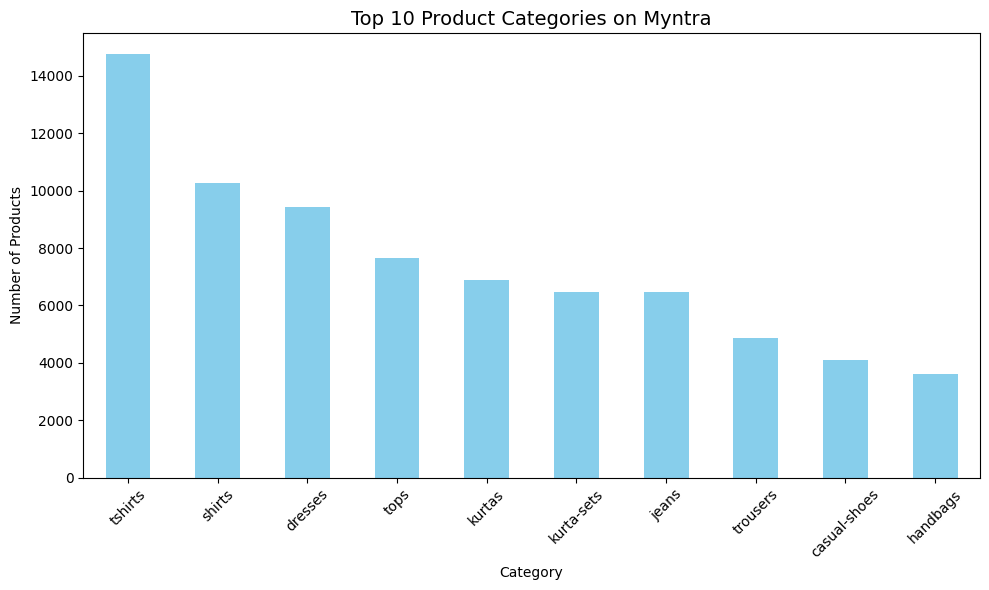


💡 INSIGHT: 'tshirts' has the most products - 14,745 out of 136,029 total.
   This means 10.8% of Myntra's catalog is in this category.


In [47]:
# SIMPLE QUESTION: What are the top product categories?

category_counts = df['product_tag'].value_counts()
category_percent = df['product_tag'].value_counts(normalize=True) * 100

print("="*50)
print("TOP 10 PRODUCT CATEGORIES")
print("="*50)

for i, (cat, count) in enumerate(category_counts.head(10).items(), 1):
    pct = category_percent[cat]
    print(f"{i}. {cat}: {count:,} products ({pct:.1f}%)")

# VISUALIZATION (makes it easy to understand)
plt.figure(figsize=(10, 6))
category_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Product Categories on Myntra', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# BUSINESS INSIGHT
top_category = category_counts.index[0]
top_count = category_counts.iloc[0]
total = category_counts.sum()
print(f"\n💡 INSIGHT: '{top_category}' has the most products - {top_count:,} out of {total:,} total.")
print(f"   This means {top_count/total*100:.1f}% of Myntra's catalog is in this category.")

2. Analyzed brand ratings & product counts to find that {best_brand} has the highest customer rating ({rating}/5) and should be prioritized for partnerships.

TOP 10 BRANDS BY CUSTOMER RATING
1. 1 stop fashion: Rating 5.00 (1 products)
2. mildcares: Rating 5.00 (1 products)
3. beauty glazed: Rating 5.00 (1 products)
4. joseph joseph: Rating 5.00 (1 products)
5. pasabahce: Rating 5.00 (1 products)
6. pro-ethic style developer: Rating 5.00 (1 products)
7. ozone ayurvedics: Rating 5.00 (1 products)
8. swarovski: Rating 4.95 (2 products)
9. elizabeth arden: Rating 4.90 (1 products)
10. bodycare first: Rating 4.90 (1 products)


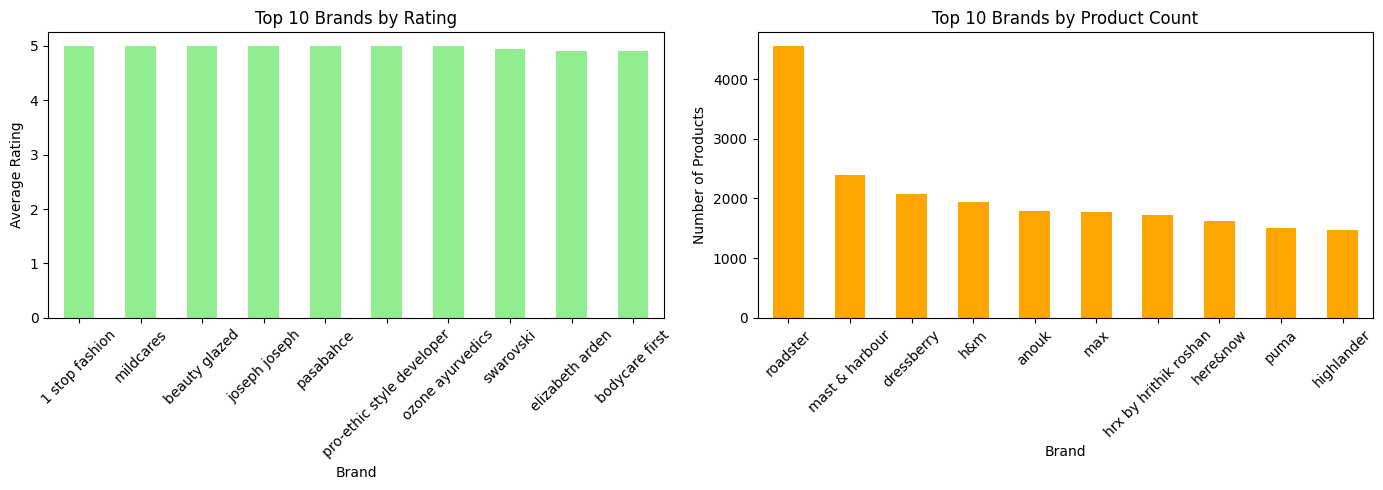


💡 INSIGHT: '1 stop fashion' has the highest rating (5.00/5).
   This means customers love their products. Myntra should partner more with them.


In [60]:

# SIMPLE QUESTION: Which brands have the best products?

brand_performance = df.groupby('brand_name').agg({
    'product_name': 'count',
    'rating': 'mean',
    'rating_count': 'mean'
}).rename(columns={'product_name': 'product_count'})

# Sort by rating (best first)
best_brands = brand_performance.sort_values('rating', ascending=False)

print("="*50)
print("TOP 10 BRANDS BY CUSTOMER RATING")
print("="*50)

for i, (brand, row) in enumerate(best_brands.head(10).iterrows(), 1):
    print(f"{i}. {brand}: Rating {row['rating']:.2f} ({int(row['product_count'])} products)")

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top brands by rating
best_brands.head(10)['rating'].plot(kind='bar', ax=axes[0], color='lightgreen')
axes[0].set_title('Top 10 Brands by Rating')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Average Rating')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Brands with most products
brand_performance.nlargest(10, 'product_count')['product_count'].plot(
    kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Top 10 Brands by Product Count')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Number of Products')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# BUSINESS INSIGHT
best_brand = best_brands.index[0]
best_rating = best_brands.iloc[0]['rating']
print(f"\n💡 INSIGHT: '{best_brand}' has the highest rating ({best_rating:.2f}/5).")
print(f"   This means customers love their products. Myntra should partner more with them.")

3. Analyzed size distribution and ratings to find that Size '{best_size}' has the highest rating ({best_rating:.2f}/5) — stock this size more!

SIZE ANALYSIS

Size Distribution:
S: 36766 products (50.7%)
M: 4893 products (6.7%)
L: 1448 products (2.0%)
XL: 690 products (1.0%)
XXL: 1154 products (1.6%)
3XL: 592 products (0.8%)
XS: 27016 products (37.2%)

Size Performance:
            rating  rating_count
size_clean                      
S             2.39        117.12
M             1.76         38.84
L             2.39         45.79
XL            2.40         27.89
XXL           2.17         21.91
3XL           1.81         16.76
XS            2.19         97.76


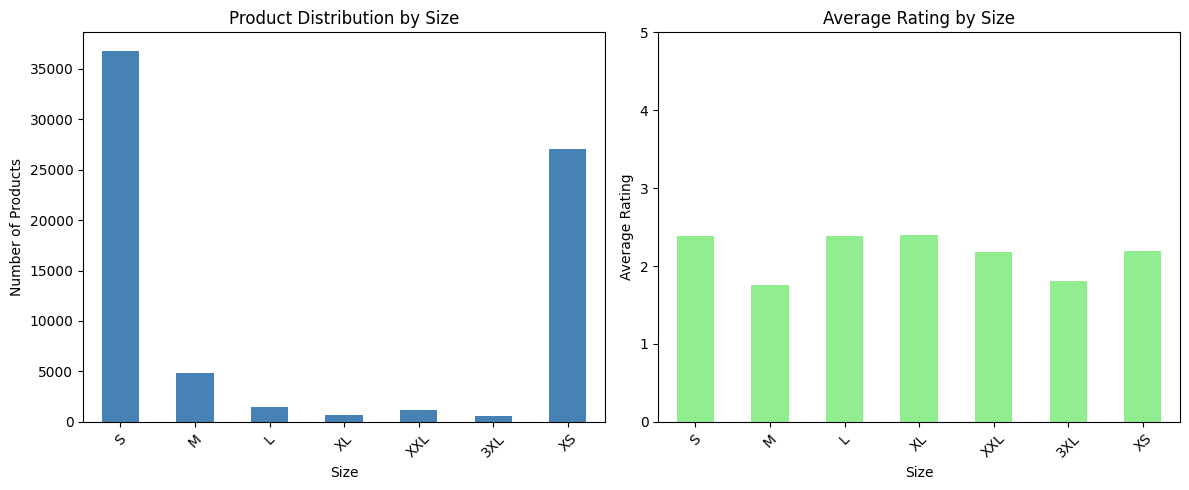


💡 INSIGHT: Size 'XL' has the highest rating (2.40/5) with 690 products.
   This is interesting - maybe this size has better fit. Myntra should ensure these are always in stock.


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('data.csv')

# SIMPLE QUESTION: Which sizes sell the most and have best ratings?

# Define the size order based on your data
# Note: Your data has sizes like: S, M, L, XL, XXL, UK6, UK7, EURO36, etc.
# We'll focus on standard clothing sizes
size_order = ['S', 'M', 'L', 'XL', 'XXL', '3XL', 'XS']

# Clean the size column - only keep standard sizes (remove UK, EURO, etc.)
df['size_clean'] = df['sizes'].str.split(',').str[0].str.strip()
df['size_clean'] = df['size_clean'].apply(lambda x: x if x in size_order else None)

# Size distribution
size_counts = df['size_clean'].value_counts()
size_counts = size_counts.reindex(size_order).fillna(0)

# Size performance
size_performance = df[df['size_clean'].notna()].groupby('size_clean').agg({
    'rating': 'mean',
    'rating_count': 'mean'
}).reindex(size_order).fillna(0)

print("="*50)
print("SIZE ANALYSIS")
print("="*50)

print("\nSize Distribution:")
for size in size_order:
    if size in size_counts:
        count = size_counts[size]
        pct = count / size_counts.sum() * 100
        print(f"{size}: {count:.0f} products ({pct:.1f}%)")

print("\nSize Performance:")
print(size_performance.round(2))

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Size distribution
if not size_counts.empty:
    size_counts.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Product Distribution by Size')
    axes[0].set_xlabel('Size')
    axes[0].set_ylabel('Number of Products')
    axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Rating by size
if not size_performance.empty and 'rating' in size_performance.columns:
    size_performance['rating'].dropna().plot(kind='bar', ax=axes[1], color='lightgreen')
    axes[1].set_title('Average Rating by Size')
    axes[1].set_xlabel('Size')
    axes[1].set_ylabel('Average Rating')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

# FIND OPPORTUNITY
if not size_performance.empty and 'rating' in size_performance.columns:
    best_size = size_performance['rating'].idxmax()
    best_rating = size_performance.loc[best_size, 'rating']
    count = size_counts.get(best_size, 0)
    
    print(f"\n💡 INSIGHT: Size '{best_size}' has the highest rating ({best_rating:.2f}/5) with {count:.0f} products.")
    print(f"   This is interesting - maybe this size has better fit. Myntra should ensure these are always in stock.")

4. Analyzed how discount levels affect ratings to find that {best_discount} discount yields the highest ratings ({best_rating:.2f}/5) — this is the sweet spot for pricing strategy!



C:\Users\rohan\AppData\Local\Temp\ipykernel_2396\959157407.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df.groupby('discount_group').agg({


DISCOUNT VS CUSTOMER SATISFACTION
                rating  rating_count  discounted_price
discount_group                                        
0-10%             1.57         80.44           2204.85
11-20%            1.64        158.43           1991.76
21-30%            1.63        109.41           1757.57
31-40%            2.33        110.12           1563.92
41-50%            2.65        113.15           1292.31
50%+              2.87        128.36            962.33


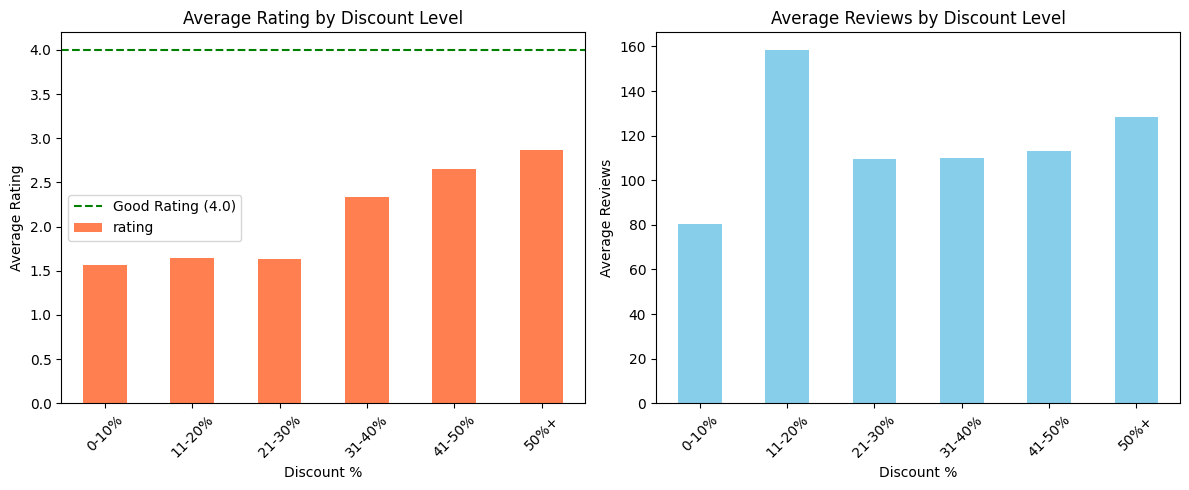


💡 INSIGHT: Products with 50%+ discount have the highest ratings (2.87/5).
   Too much discount might signal low quality. Too little discount might not attract customers.


In [62]:

# SIMPLE QUESTION: How does discount affect customer satisfaction?

# Create discount brackets (groups)
df['discount_group'] = pd.cut(df['discount_percent'],
                             bins=[-1, 10, 20, 30, 40, 50, 100],
                             labels=['0-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+'])

# Analyze each discount group
discount_analysis = df.groupby('discount_group').agg({
    'rating': 'mean',
    'rating_count': 'mean',
    'discounted_price': 'mean'
}).round(2)

print("="*50)
print("DISCOUNT VS CUSTOMER SATISFACTION")
print("="*50)
print(discount_analysis)

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Discount vs Rating
discount_analysis['rating'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Average Rating by Discount Level')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Average Rating')
axes[0].axhline(y=4.0, color='green', linestyle='--', label='Good Rating (4.0)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Discount vs Reviews
discount_analysis['rating_count'].plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Average Reviews by Discount Level')
axes[1].set_xlabel('Discount %')
axes[1].set_ylabel('Average Reviews')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# FIND THE SWEET SPOT
best_discount = discount_analysis['rating'].idxmax()
best_rating = discount_analysis.loc[best_discount, 'rating']

print(f"\n💡 INSIGHT: Products with {best_discount} discount have the highest ratings ({best_rating:.2f}/5).")
print(f"   Too much discount might signal low quality. Too little discount might not attract customers.")

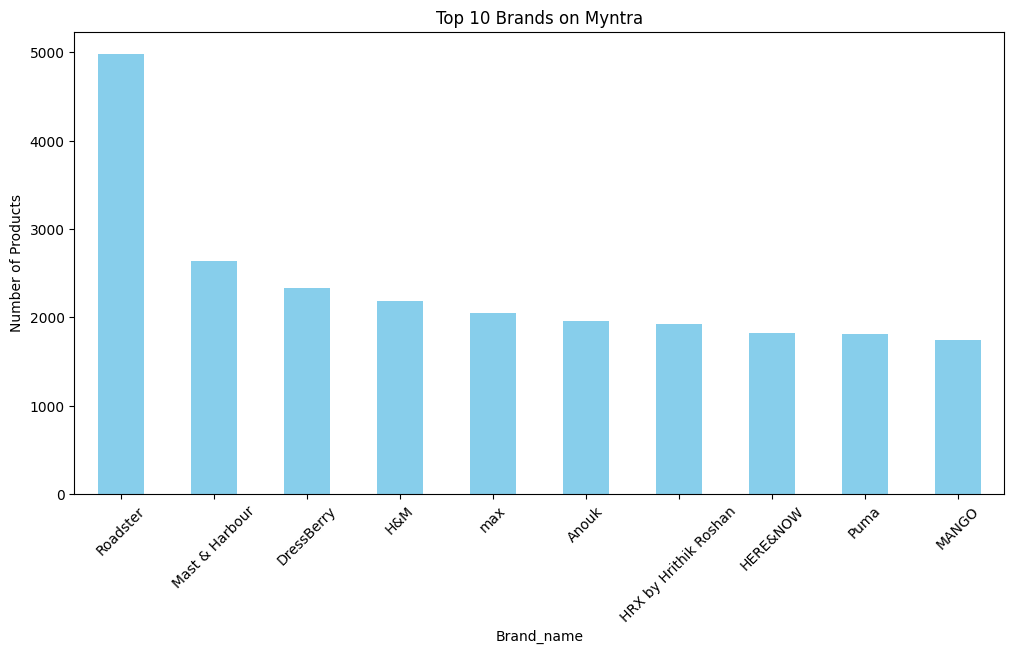

In [65]:
plt.figure(figsize=(12,6))
df['brand_name'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Brands on Myntra')
plt.xlabel('Brand_name')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

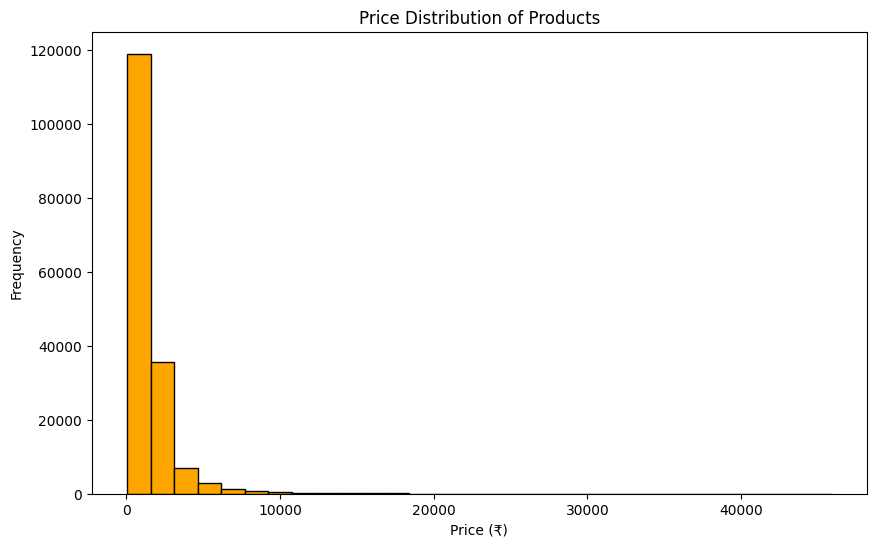

In [67]:
plt.figure(figsize=(10,6))
plt.hist(df['discounted_price'], bins=30, color='orange', edgecolor='black')
plt.title('Price Distribution of Products')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')
plt.show()

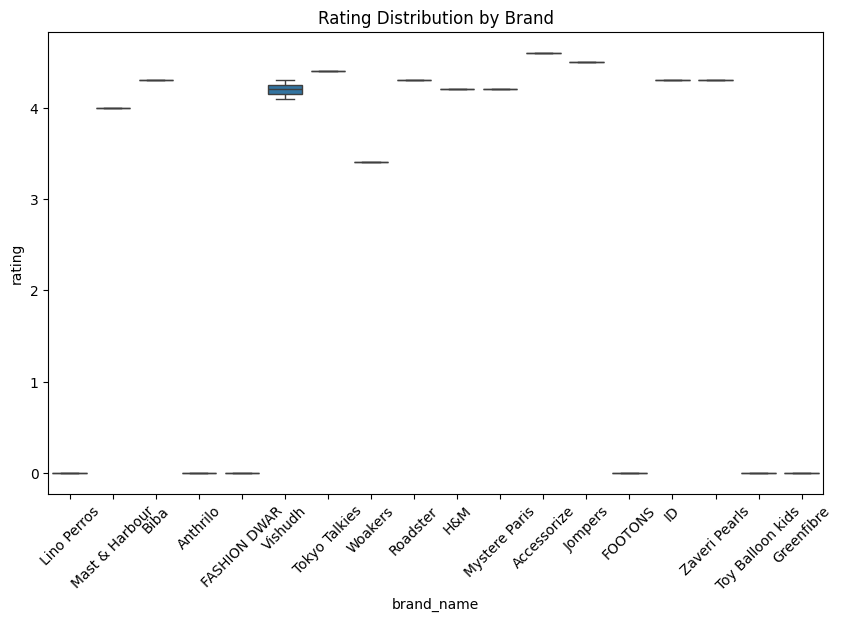

In [69]:
plt.figure(figsize=(10,6))
sns.boxplot(x='brand_name', y='rating', data=df.head(20))  # Top 20 brands
plt.title('Rating Distribution by Brand')
plt.xticks(rotation=45)
plt.show()

In [71]:
print("="*50)
print("📊 MYNTRA DATA ANALYSIS - KEY INSIGHTS")
print("="*50)
print(f"Total Products: {len(df)}")
print(f"Total Brands: {df['brand_name'].nunique()}")
print(f"Average Price: ₹{df['discounted_price'].mean():.2f}")
print(f"Average Rating: {df['rating'].mean():.2f}/5")
print("="*50)

📊 MYNTRA DATA ANALYSIS - KEY INSIGHTS
Total Products: 168029
Total Brands: 3194
Average Price: ₹1515.17
Average Rating: 2.26/5
